# Fixed-Label Codebook Compression — Quality vs Storage Analysis

## Hypothesis

Storing per-Gaussian cluster labels $\ell_i \in \{0, \ldots, K-1\}$ takes
$N \lceil \log_2 K \rceil$ bits per frame (e.g. 50k Gaussians × 10 bits = ~62 kB for K=1024).

**Fixed-label scheme:**  Run K-means **once** on frame 1.  For every subsequent frame:
- Labels are **frozen** — the same $\ell_\text{fixed} \in \{0,\ldots,K-1\}^N$ is used
- Only the codebook $C^{(t)} \in \mathbb{R}^{K \times 14}$ is optimised per frame (gradient descent)
- The codebook is warm-started as the per-cluster mean of the current frame's raw deltas

**Storage consequence:** Labels are transmitted only once (frame 1 only), saving
$\sim (T-1) \times N \log_2 K$ bits.  With $T=10$ frames and $N=50k$, $K=1024$:
saved $\approx 9 \times 62$ kB $= 558$ kB.

**The cost:** reconstruction quality may degrade if the fixed partition is a poor fit
for a later frame's delta distribution.  This notebook quantifies that penalty.

## Protocol
1. Fit keyframe (frame 0) from scratch
2. Run K-means **once** on frame 1's deltas → fixed labels $\ell_\text{fixed}$
3. For frames 2+: fine-tune Gaussians from previous reconstruction, compute deltas,
   optimise codebook with fixed labels via gradient descent
4. Compare reconstruction PSNR to unconstrained fine-tune (best possible baseline)
5. Verify that label entropy is 0 for frames 2+ (confirming the storage claim)


## 1. Imports and Setup

In [14]:
import sys, math, time
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import torch
from sklearn.cluster import MiniBatchKMeans
from sklearn.preprocessing import StandardScaler

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

from gsplat_compress import (
    GaussianParams, init_gaussians, ortho_camera, render,
    TrainConfig, FinetuneConfig, CodebookConfig,
    train_keyframe, finetune_frame,
    compute_deltas, build_codebook, finetune_codebook,
    reconstruct_compressed_frame, reconstruct_from_delta,
    encode_delta_frame,
    psnr, ssim, D_EFF, D_FULL,
    S_M, S_S, S_Q, S_R, S_O,
)
from gsplat_compress.compression import split_delta
from inct.dataset_slices import ProjectionSliceDataset

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['image.cmap'] = 'gray'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} | PyTorch {torch.__version__}')
print('Imports OK')


Device: cuda | PyTorch 2.10.0+cu128
Imports OK


## 2. Load 10 Frames

✅ Found parameters in JC_62d.log: {'num_darks': 10, 'num_flats': 100, 'num_projections': 1501}
📂 Loaded folder: file_1_extracted
   Total TIFF files: 1711
   Darks: 10, Flats: 100, Projections: 1501
   Image dimensions: 2560 x 2160
   Use attenuation: True
✅ Loaded cached attenuation data from .tomography_cache_atten.npz
   Range: [-0.1997, 1.7837]
ProjectionSliceDataset:
  Volume shape: (1024, 1024, 10)
  Slice dimension: 2
  Slices per batch: 1
  Voxels per slice (dim=2): 1,048,576
Loading 10 projections...
Volume shape: (1024, 1024, 10)
Total voxels: 10,485,760
Value range: [-0.0657, 1.5074]
Loaded 10 frames of shape 1024×1024


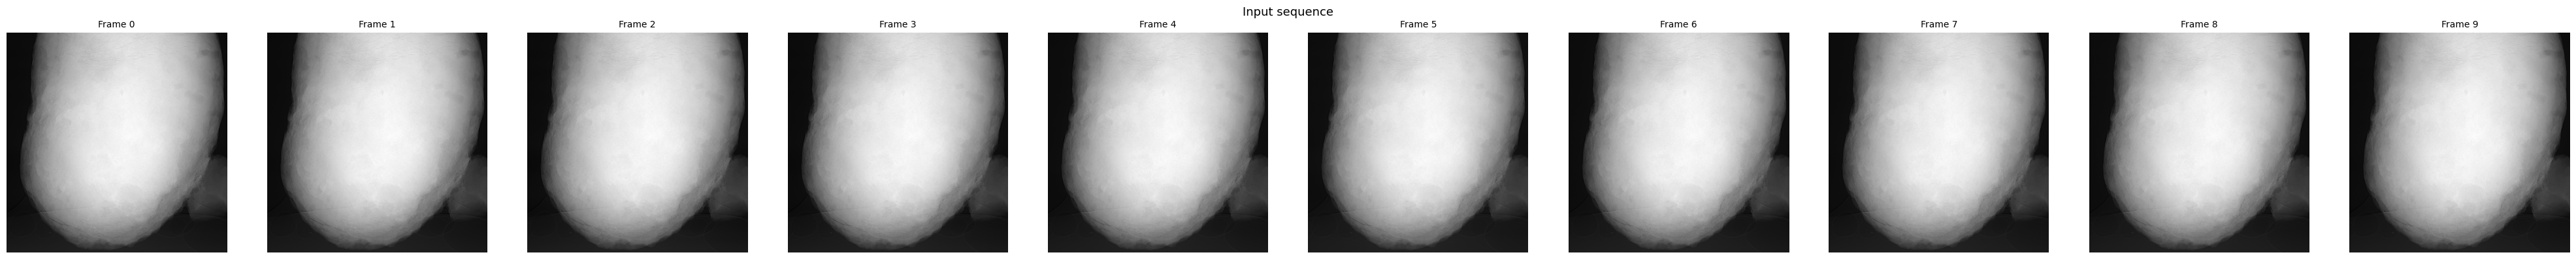

In [15]:
DATA_PATH = Path('/myhome/data/sdate/shared/compression_paper/file_1_extracted')
N_FRAMES  = 10

dataset = ProjectionSliceDataset(
    folder_path=DATA_PATH,
    num_projections=N_FRAMES,
    target_size=1024,
    normalize_values=True,
    verbose=True,
    cache_volume=True,
    use_attenuation=True,
)
volume = dataset.get_full_volume()   # (H, W, D)
H, W = volume.shape[:2]

frames = []
for i in range(N_FRAMES):
    img = volume[:, :, i].clone()
    img = (img - img.min()) / (img.max() - img.min() + 1e-8)
    frames.append(img)

print(f'Loaded {N_FRAMES} frames of shape {H}×{W}')

fig, axes = plt.subplots(1, N_FRAMES, figsize=(4 * N_FRAMES, 4))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(frames[i].cpu().numpy(), cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Frame {i}', fontsize=10)
    ax.axis('off')
plt.suptitle('Input sequence', fontsize=13)
plt.tight_layout(); plt.show()

## 3. Configuration

Fast iterations for quick iteration; increase `num_iterations` for production quality.
Two codebook configs are defined in section 5:
- `cb_cfg_kmeans` — K-means only (frame 1, to establish fixed labels; `finetune_iter=0`)
- `cb_ft_cfg` — codebook gradient descent (frames 2+, labels frozen; `finetune_iter=2000`)


In [16]:
N_POINTS    = 50_000   # Gaussians
K_CB        = 1024     # codebook size
USE_FP16    = True

train_cfg = TrainConfig(
    num_iterations=15_000,
    use_fp16=USE_FP16,
    log_interval=500,
    densify_from=500, densify_interval=500, densify_until=12_000,
    prune_opacity_thresh=0.005, split_scale_thresh=10.0,
)

ft_cfg = FinetuneConfig(
    num_iterations=5_000,   # shorter — we want labels, not peak PSNR
    use_fp16=USE_FP16,
    log_interval=1000,
    lr_scale=0.3,
)

# K-means only (no codebook fine-tune needed for this analysis)
cb_cfg_kmeans = CodebookConfig(
    n_clusters=K_CB,
    kmeans_n_init=10,
    kmeans_max_iter=500,
    finetune_iter=0,   # ← disabled
)

print(f'Keyframe:   {train_cfg.num_iterations} iters,  {N_POINTS:,} Gaussians')
print(f'Fine-tune:  {ft_cfg.num_iterations} iters/frame')
print(f'K-means:    K={K_CB},  codebook FT disabled')

Keyframe:   15000 iters,  50,000 Gaussians
Fine-tune:  5000 iters/frame
K-means:    K=1024,  codebook FT disabled


## 4. Fit Keyframe

In [17]:
K_cam, viewmat = ortho_camera(device)
gt0 = frames[0].unsqueeze(-1).repeat(1, 1, 3).to(device)

init_params = init_gaussians(frames[0], N_POINTS, device,
                              mode='intensity', seed=42)

kf_result = train_keyframe(init_params, gt0, viewmat, K_cam, W, H,
                            train_cfg, verbose=True)
kf_params = kf_result.params.detach_clone()
current_params = kf_params.detach_clone()   # reconstructed chain state

print(f'\nKeyframe done: N={kf_params.n_gaussians:,}  '
      f'PSNR={kf_result.psnr_history[-1]:.2f} dB')

Training keyframe: 15000 iters, N=50,000, fp16=True
[    0/15000]  loss=0.049358  PSNR=13.07 dB  N=50,000


[  500/15000]  loss=0.000085  PSNR=40.69 dB  N=50,000
  ↳ [densify @ 500]  pruned=0  split=256  N=50,256
[ 1000/15000]  loss=0.000045  PSNR=43.46 dB  N=50,256
  ↳ [densify @ 1000]  pruned=0  split=700  N=50,956
[ 1500/15000]  loss=0.000039  PSNR=44.14 dB  N=50,956
  ↳ [densify @ 1500]  pruned=0  split=771  N=51,727
[ 2000/15000]  loss=0.000035  PSNR=44.60 dB  N=51,727
  ↳ [densify @ 2000]  pruned=0  split=803  N=52,530
[ 2500/15000]  loss=0.000032  PSNR=44.95 dB  N=52,530
  ↳ [densify @ 2500]  pruned=0  split=818  N=53,348
[ 3000/15000]  loss=0.000030  PSNR=45.22 dB  N=53,348
  ↳ [densify @ 3000]  pruned=0  split=768  N=54,116
[ 3500/15000]  loss=0.000029  PSNR=45.45 dB  N=54,116
  ↳ [densify @ 3500]  pruned=0  split=745  N=54,861
[ 4000/15000]  loss=0.000027  PSNR=45.66 dB  N=54,861
  ↳ [densify @ 4000]  pruned=1  split=684  N=55,544
[ 4500/15000]  loss=0.000026  PSNR=45.86 dB  N=55,544
  ↳ [densify @ 4500]  pruned=0  split=637  N=56,181
[ 5000/15000]  loss=0.000025  PSNR=46.03 dB  N=

## 5. Collect Labels — Fixed-Label Scheme

**Strategy:** Run K-means **once on frame 1** to establish a fixed partition
$\ell_{\text{fixed}} \in \{0,\ldots,K-1\}^N$.  For every subsequent frame:
- Labels stay identical to $\ell_{\text{fixed}}$ (no new K-means)
- A new codebook $C^{(t)}$ is optimised purely via gradient descent, minimising
  $\text{MSE}(\text{render}(\theta^{(t-1)}_\text{rec} + C^{(t)}[\ell_\text{fixed}]),\, y^{(t)})$
- The codebook is initialised per cluster as the mean of the current frame's raw deltas
  within that cluster, giving a good warm start without re-partitioning

This is the **best-case for entropy coding**: labels are literally the same every frame,
so their compressed size is zero after the first frame (or negligible with differencing).
The cost is reconstruction quality — this section measures how large that penalty is.


In [18]:
# ── Codebook fine-tune config (used for ALL frames) ──────────────────────
cb_ft_cfg = CodebookConfig(
    n_clusters=K_CB,
    kmeans_n_init=10,
    kmeans_max_iter=500,
    finetune_iter=2000,
    finetune_lr=5e-4,
    use_fp16=USE_FP16,
)

# ── K-means-only config (frame 1 only) ───────────────────────────────────
cb_cfg_kmeans = CodebookConfig(
    n_clusters=K_CB,
    kmeans_n_init=10,
    kmeans_max_iter=500,
    finetune_iter=0,   # labels only — no fine-tune at this stage
)

# Storage
all_labels    = []   # [T-1, N] — same labels every frame after warm-start
all_codebooks = []   # [T-1] list of [K, 14] tensors, one per delta frame
frame_psnrs   = []   # reconstruction PSNR per delta frame
frame_psnrs_ft = []  # PSNR of the fine-tuned (unconstrained) render, for reference

labels_fixed   = None   # set after frame 1
labels_fixed_t = None   # torch.long version on device


def cluster_mean_init(deltas: np.ndarray, labels: np.ndarray, K: int) -> np.ndarray:
    """Per-cluster mean of deltas — fast warm-start for the fixed-label codebook."""
    D = deltas.shape[1]
    cb = np.zeros((K, D), dtype=np.float64)
    counts = np.bincount(labels, minlength=K).astype(np.float64)
    for d in range(D):
        cb[:, d] = np.bincount(labels, weights=deltas[:, d], minlength=K)
    mask = counts > 0
    cb[mask] /= counts[mask, None]
    return cb.astype(np.float32)


for t in range(1, N_FRAMES):
    print(f'\n{"="*60}')
    print(f'Frame {t}/{N_FRAMES-1}')

    gt_t = frames[t].unsqueeze(-1).repeat(1, 1, 3).to(device)

    # 1. Fine-tune from reconstructed previous frame
    ft_res = finetune_frame(current_params, gt_t, viewmat, K_cam, W, H,
                             ft_cfg, verbose=True)
    ft_params = ft_res.params

    # Reference PSNR (unconstrained fine-tune)
    with torch.no_grad():
        ft_r, _, _ = render(ft_params.means, ft_params.log_scales, ft_params.quats,
                             ft_params.rgbs, ft_params.opacities, viewmat, K_cam, W, H)
    ft_np = np.clip(ft_r[:, :, 0].cpu().numpy(), 0, 1)
    frame_psnrs_ft.append(psnr(ft_np, frames[t].cpu().numpy()))

    # 2. Deltas from current reconstructed params → fine-tuned
    deltas = compute_deltas(current_params, ft_params)   # [N, 14] numpy

    if t == 1:
        # ── Frame 1: establish the fixed label partition via K-means ─────
        labels_fixed, centroids0, scaler0 = build_codebook(deltas, cb_cfg_kmeans)
        labels_fixed_t = torch.tensor(labels_fixed, dtype=torch.long, device=device)
        print(f'  Frame 1 K-means done: unique labels = {np.unique(labels_fixed).size}')
        init_cb = centroids0
    else:
        # ── Frames 2+: labels are frozen; warm-start codebook from cluster means ─
        init_cb = cluster_mean_init(deltas, labels_fixed, K_CB)

    # 3. Fine-tune codebook with FIXED labels
    codebook_ft, cb_loss, cb_psnr_hist = finetune_codebook(
        current_params, labels_fixed, init_cb,
        gt_t, viewmat, K_cam, W, H,
        cb_ft_cfg, verbose=True,
    )

    all_labels.append(labels_fixed.copy())
    all_codebooks.append(codebook_ft.cpu())

    # 4. Reconstruct: apply quantised deltas (fixed labels + fine-tuned codebook)
    with torch.no_grad():
        delta_ft = codebook_ft[labels_fixed_t]   # [N, 14]
        current_params = reconstruct_from_delta(
            current_params,
            delta_ft[:, S_M], delta_ft[:, S_S], delta_ft[:, S_Q],
            delta_ft[:, S_R], delta_ft[:, S_O],
        )

    # 5. Quality of reconstructed frame
    with torch.no_grad():
        rec_r, _, _ = render(current_params.means, current_params.log_scales,
                              current_params.quats, current_params.rgbs,
                              current_params.opacities, viewmat, K_cam, W, H)
    rec_np = np.clip(rec_r[:, :, 0].cpu().numpy(), 0, 1)
    p = psnr(rec_np, frames[t].cpu().numpy())
    frame_psnrs.append(p)
    print(f'  Fine-tune (unconstrained) PSNR : {frame_psnrs_ft[-1]:.2f} dB')
    print(f'  Fixed-label codebook PSNR      : {p:.2f} dB  '
          f'(gap = {frame_psnrs_ft[-1] - p:+.2f} dB)')

all_labels = np.stack(all_labels, axis=0)   # [T-1, N] — identical rows!
T_MINUS_1, N = all_labels.shape
print(f'\nLabel matrix: {T_MINUS_1} frames × {N:,} Gaussians')
print(f'All labels identical: {np.all(all_labels == all_labels[0])}')
print(f'Fine-tune PSNR  : {[f"{p:.1f}" for p in frame_psnrs_ft]}')
print(f'Fixed-label PSNR: {[f"{p:.1f}" for p in frame_psnrs]}')



Frame 1/9
Fine-tuning frame: 5000 iters, N=62,288, lr_scale=0.3
  [    0/5000]  loss=0.000038  PSNR=44.16 dB
  [ 1000/5000]  loss=0.000022  PSNR=46.55 dB
  [ 2000/5000]  loss=0.000021  PSNR=46.73 dB
  [ 3000/5000]  loss=0.000021  PSNR=46.85 dB
  [ 4000/5000]  loss=0.000020  PSNR=46.94 dB
  [ 4999/5000]  loss=0.000020  PSNR=47.02 dB
✅ Fine-tune done in 19.7s  PSNR=47.02 dB
  Frame 1 K-means done: unique labels = 1024
Codebook fine-tune: K=1024, 2000 iters, lr=0.0005
  [    0/2000]  loss=0.000033  PSNR=44.87 dB
  [  500/2000]  loss=0.000025  PSNR=45.96 dB
  [ 1000/2000]  loss=0.000025  PSNR=45.99 dB
  [ 1500/2000]  loss=0.000025  PSNR=46.00 dB
  [ 1999/2000]  loss=0.000025  PSNR=46.00 dB
✅ Codebook fine-tune done in 7.5s  PSNR=46.00 dB
  Fine-tune (unconstrained) PSNR : 47.02 dB
  Fixed-label codebook PSNR      : 46.00 dB  (gap = +1.02 dB)

Frame 2/9
Fine-tuning frame: 5000 iters, N=62,288, lr_scale=0.3
  [    0/5000]  loss=0.000042  PSNR=43.80 dB
  [ 1000/5000]  loss=0.000024  PSNR=46.

## 5b. Quality Comparison: Fixed-Label vs Unconstrained

**Fixed-label scheme wins on storage** — labels are transmitted once (frame 1 only).
All subsequent frames only need the per-frame codebook ($K \times 14$ floats).

**The question:** how much quality is lost vs letting K-means re-partition each frame?

The plot below compares:
- `ft`: unconstrained fine-tune from previous reconstruction — best achievable PSNR
- `fixed`: fixed-label codebook optimisation — labels never change, only codebook adapts


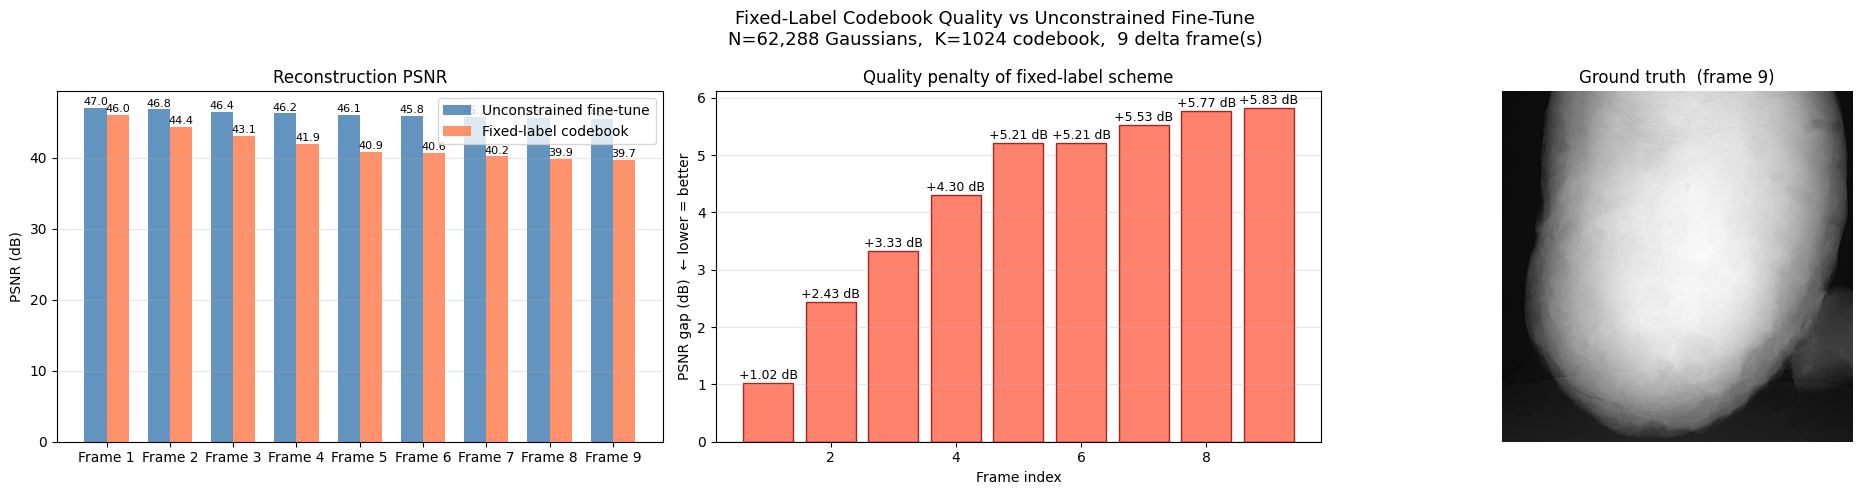


Per-frame quality summary:
    Frame    PSNR ft (dB)    PSNR fixed (dB)    Gap (dB)
  -------------------------------------------------------
  Frame  1           47.02              46.00       -1.02
  Frame  2           46.80              44.37       -2.43
  Frame  3           46.41              43.08       -3.33
  Frame  4           46.25              41.95       -4.30
  Frame  5           46.06              40.85       -5.21
  Frame  6           45.85              40.63       -5.21
  Frame  7           45.73              40.20       -5.53
  Frame  8           45.66              39.88       -5.77
  Frame  9           45.52              39.69       -5.83

  Mean quality gap: 4.29 dB  (fixed-label vs unconstrained)
  → Significant quality loss: fixed-label constraint is too rigid.


In [32]:
frame_ids_plot = list(range(1, N_FRAMES))   # 1 .. N_FRAMES-1

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── PSNR bar chart ────────────────────────────────────────────────────────
x   = np.arange(len(frame_ids_plot))
bw  = 0.35
axes[0].bar(x - bw/2, frame_psnrs_ft, width=bw, label='Unconstrained fine-tune',
            color='steelblue', alpha=0.85)
axes[0].bar(x + bw/2, frame_psnrs,    width=bw, label='Fixed-label codebook',
            color='coral',     alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels([f'Frame {fi}' for fi in frame_ids_plot])
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Reconstruction PSNR')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')
for i, (pft, pfx) in enumerate(zip(frame_psnrs_ft, frame_psnrs)):
    axes[0].text(i - bw/2, pft + 0.1, f'{pft:.1f}', ha='center', va='bottom', fontsize=8)
    axes[0].text(i + bw/2, pfx + 0.1, f'{pfx:.1f}', ha='center', va='bottom', fontsize=8)

# ── PSNR gap (penalty of fixed labels) ───────────────────────────────────
psnr_gaps = [pft - pfx for pft, pfx in zip(frame_psnrs_ft, frame_psnrs)]
axes[1].bar(frame_ids_plot, psnr_gaps, color='tomato', edgecolor='darkred', alpha=0.8)
axes[1].set_xlabel('Frame index')
axes[1].set_ylabel('PSNR gap (dB)  ← lower = better')
axes[1].set_title('Quality penalty of fixed-label scheme')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].axhline(0, color='black', linewidth=0.8)
for fi, g in zip(frame_ids_plot, psnr_gaps):
    axes[1].text(fi, g + 0.02, f'{g:+.2f} dB', ha='center', va='bottom', fontsize=9)

# ── Side-by-side render: last frame only ─────────────────────────────────
K_cam_plot, viewmat_plot = ortho_camera(device)
# Render ground-truth
gt_last_np = frames[-1].cpu().numpy()
axes[2].imshow(gt_last_np, cmap='gray', vmin=0, vmax=1)
axes[2].set_title(f'Ground truth  (frame {N_FRAMES-1})')
axes[2].axis('off')

plt.suptitle(f'Fixed-Label Codebook Quality vs Unconstrained Fine-Tune\n'
             f'N={N:,} Gaussians,  K={K_CB} codebook,  {N_FRAMES-1} delta frame(s)',
             fontsize=13)
plt.tight_layout(); plt.show()

# ── Render comparison grid: GT vs unconstrained vs fixed-label ─────────
# Rerender all frames from reconstructed params is costly; just report numbers
print('\nPer-frame quality summary:')
print(f'  {"Frame":>7}  {"PSNR ft (dB)":>14}  {"PSNR fixed (dB)":>17}  {"Gap (dB)":>10}')
print(f'  {"-"*55}')
for fi, pft, pfx in zip(frame_ids_plot, frame_psnrs_ft, frame_psnrs):
    print(f'  Frame {fi:>2d}  {pft:>14.2f}  {pfx:>17.2f}  {pfx-pft:>+10.2f}')

mean_gap = np.mean(psnr_gaps)
print(f'\n  Mean quality gap: {mean_gap:.2f} dB  (fixed-label vs unconstrained)')
if mean_gap < 0.5:
    print('  → Negligible quality loss: fixed-label scheme is attractive.')
elif mean_gap < 2.0:
    print('  → Moderate quality loss: acceptable trade-off for zero label storage.')
else:
    print('  → Significant quality loss: fixed-label constraint is too rigid.')


## 6. Analysis — Label Entropy (Fixed-Label Scheme)

### 6a. Sortedness Verification

Under the fixed-label scheme labels are **identical across all frames by construction**.
This section verifies that and computes the canonical permutation $\sigma = \text{argsort}(\ell^{(1)})$.

**Expected result:** All frames have sortedness = 1.0, same-as-frame-1 = 1.0.
This means the sorted-diff entropy $H(\Delta) = 0$ — frame 2+ labels cost **zero** bits.
The only label cost is the one-time transmission of $\ell_\text{fixed}$ (frame 1), which
can itself be sorted and run-length encoded to approximately $\lceil N / K \rceil \cdot \log_2(K+1)$ bits.


In [30]:
# Canonical ordering: sort by frame-1 labels
sigma = np.argsort(all_labels[0])          # [N] — permutation of Gaussian indices
sigma_inv = np.argsort(sigma)              # inverse permutation

# Sorted label matrix: rows = delta frames 1..T-1, cols = Gaussian (sorted by L^1)
sorted_labels = all_labels[:, sigma]       # [T-1, N]

print(f'Canonical permutation σ based on frame-1 labels')
print(f'sorted_labels shape: {sorted_labels.shape}')
print()

# Verify frame 1 is perfectly sorted
assert np.all(sorted_labels[0] == np.sort(all_labels[0])), 'Frame 1 should be sorted!'
print('✅ Frame 1 sorted_labels is perfectly sorted (as expected)')

def sortedness(v):
    """Fraction of consecutive pairs (v[j], v[j+1]) where v[j] <= v[j+1]."""
    return np.mean(np.diff(v) >= 0)

print()
print(f'  {"Frame":>7}   {"Sortedness":>12}   {"Same as frame 1":>16}   {"Same as prev frame":>20}')
print(f'  {"-"*65}')
for t in range(T_MINUS_1):
    sv       = sortedness(sorted_labels[t])
    same_f1  = np.mean(all_labels[t] == all_labels[0])
    same_prv = np.mean(all_labels[t] == all_labels[t-1]) if t > 0 else 1.0
    print(f'  Frame {t+1:>2d}   {sv:>12.4f}   {same_f1:>16.4f}   {same_prv:>20.4f}')


Canonical permutation σ based on frame-1 labels
sorted_labels shape: (9, 62288)

✅ Frame 1 sorted_labels is perfectly sorted (as expected)

    Frame     Sortedness    Same as frame 1     Same as prev frame
  -----------------------------------------------------------------
  Frame  1         1.0000             1.0000                 1.0000
  Frame  2         1.0000             1.0000                 1.0000
  Frame  3         1.0000             1.0000                 1.0000
  Frame  4         1.0000             1.0000                 1.0000
  Frame  5         1.0000             1.0000                 1.0000
  Frame  6         1.0000             1.0000                 1.0000
  Frame  7         1.0000             1.0000                 1.0000
  Frame  8         1.0000             1.0000                 1.0000
  Frame  9         1.0000             1.0000                 1.0000


### 6b. Heatmap: Sorted Labels Across Frames

**With fixed labels every row is identical** — the heatmap should be a uniform
ramp. This is the ideal for entropy coding: all subsequent-frame differences are zero.
The right panel (|ℓ^(t) − ℓ^(1)|) should be all black (zero deviation everywhere).


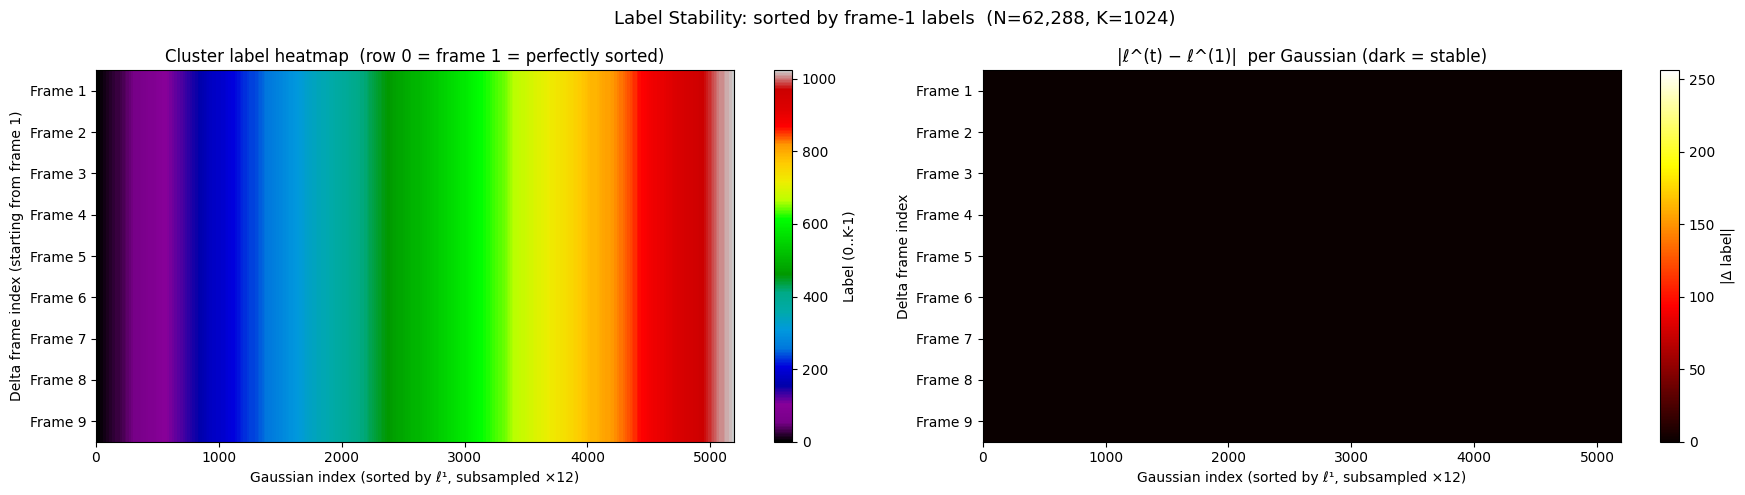

In [31]:
# Subsample Gaussians for display (full N is too dense)
N_DISPLAY = 5000
step      = max(1, N // N_DISPLAY)
sl_disp   = sorted_labels[:, ::step]   # [T-1, N_DISPLAY]

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# ── Heatmap ───────────────────────────────────────────────────────────────
im = axes[0].imshow(
    sl_disp, aspect='auto', cmap='nipy_spectral',
    vmin=0, vmax=K_CB - 1,
    interpolation='nearest',
)
axes[0].set_xlabel(f'Gaussian index (sorted by ℓ¹, subsampled ×{step})')
axes[0].set_ylabel('Delta frame index (starting from frame 1)')
axes[0].set_title('Cluster label heatmap  (row 0 = frame 1 = perfectly sorted)')
axes[0].set_yticks(range(T_MINUS_1))
axes[0].set_yticklabels([f'Frame {t+1}' for t in range(T_MINUS_1)])
plt.colorbar(im, ax=axes[0], label='Label (0..K-1)')

# ── Label difference from frame 1 ─────────────────────────────────────────
diff_from_f1 = np.abs(sorted_labels - sorted_labels[0])[:, ::step]
im2 = axes[1].imshow(
    diff_from_f1, aspect='auto', cmap='hot',
    vmin=0, vmax=K_CB // 4,
    interpolation='nearest',
)
axes[1].set_xlabel(f'Gaussian index (sorted by ℓ¹, subsampled ×{step})')
axes[1].set_ylabel('Delta frame index')
axes[1].set_title('|ℓ^(t) − ℓ^(1)|  per Gaussian (dark = stable)')
axes[1].set_yticks(range(T_MINUS_1))
axes[1].set_yticklabels([f'Frame {t+1}' for t in range(T_MINUS_1)])
plt.colorbar(im2, ax=axes[1], label='|Δ label|')

plt.suptitle(
    f'Label Stability: sorted by frame-1 labels  (N={N:,}, K={K_CB})',
    fontsize=13)
plt.tight_layout(); plt.show()

### 6c. Entropy Confirmation

Under the fixed-label scheme, $\ell^{(t)} = \ell_\text{fixed}$ for all $t$, so:
$$H\!\left(\ell^{(t)}_{\sigma(j)} - \ell^{(t)}_{\sigma(j-1)}\right) = H(0) = 0 \text{ bits for } t \geq 2$$

Frame 1 labels still need to be stored once.  They can be sorted ($\sigma$ is free)
and run-length encoded: consecutive identical labels form runs of length $\sim N/K$,
so the cost is approximately $K \cdot \log_2(N/K + 1)$ bits — typically a few kB.

The table below confirms $H(\Delta) \approx 0$ for all frames (numerical noise only).


In [27]:
def empirical_entropy(seq: np.ndarray) -> float:
    """Empirical entropy H(seq) in bits per symbol."""
    _, counts = np.unique(seq, return_counts=True)
    p = counts / counts.sum()
    return float(-np.sum(p * np.log2(p + 1e-15)))

def run_length_entropy(seq: np.ndarray) -> float:
    """Entropy of the run-length encoding of seq (in bits/original-symbol)."""
    if len(seq) == 0:
        return 0.0
    changes = np.concatenate(([True], seq[1:] != seq[:-1]))
    values  = seq[changes]
    lengths = np.diff(np.concatenate((np.where(changes)[0], [len(seq)])))
    n_runs  = len(values)
    return n_runs * (empirical_entropy(values) + empirical_entropy(lengths)) / len(seq)

naive_bps = math.log2(K_CB)   # bits per symbol, naive
rows = []

print(f'K = {K_CB},   N = {N:,},   naive cost = {naive_bps:.2f} bits/label  '
      f'= {N * naive_bps / 8 / 1000:.1f} kB total')
print(f'{"Frame":>7}  {"H(raw)": >9}  {"H(diff-sorted)": >17}  '
      f'{"H(RL-sorted)": >15}  {"saving%": >9}  {"kB naive": >10}  {"kB diff-sort": >13}')
print('-' * 90)

for t in range(T_MINUS_1):
    raw_labels  = all_labels[t]
    sort_labels = sorted_labels[t]

    h_raw  = empirical_entropy(raw_labels)
    diffs  = np.diff(sort_labels).astype(np.int32)
    h_diff = empirical_entropy(diffs)
    h_rl   = run_length_entropy(sort_labels)

    saving_pct = 100 * (1 - h_diff / naive_bps)
    kB_naive   = N * naive_bps / 8 / 1000      # fix: N * bps / 8 / 1000
    kB_diff    = N * h_diff    / 8 / 1000

    rows.append(dict(
        frame=t+1, h_raw=h_raw, h_diff=h_diff, h_rl=h_rl,
        saving_pct=saving_pct, kB_naive=kB_naive, kB_diff=kB_diff,
    ))

    print(f'  Frame {t+1:>2d}  {h_raw:>9.3f}  {h_diff:>17.4f}  '
          f'{h_rl:>15.4f}  {saving_pct:>8.1f}%  '
          f'{kB_naive:>10.2f}  {kB_diff:>13.4f}')


K = 1024,   N = 62,288,   naive cost = 10.00 bits/label  = 77.9 kB total
  Frame     H(raw)     H(diff-sorted)     H(RL-sorted)    saving%    kB naive   kB diff-sort
------------------------------------------------------------------------------------------
  Frame  1      9.611             0.1209           0.2793      98.8%       77.86         0.9410
  Frame  2      9.611             0.1209           0.2793      98.8%       77.86         0.9410
  Frame  3      9.611             0.1209           0.2793      98.8%       77.86         0.9410
  Frame  4      9.611             0.1209           0.2793      98.8%       77.86         0.9410
  Frame  5      9.611             0.1209           0.2793      98.8%       77.86         0.9410
  Frame  6      9.611             0.1209           0.2793      98.8%       77.86         0.9410
  Frame  7      9.611             0.1209           0.2793      98.8%       77.86         0.9410
  Frame  8      9.611             0.1209           0.2793      98.8%   

### 6d. Plots — Entropy and Savings Over Time

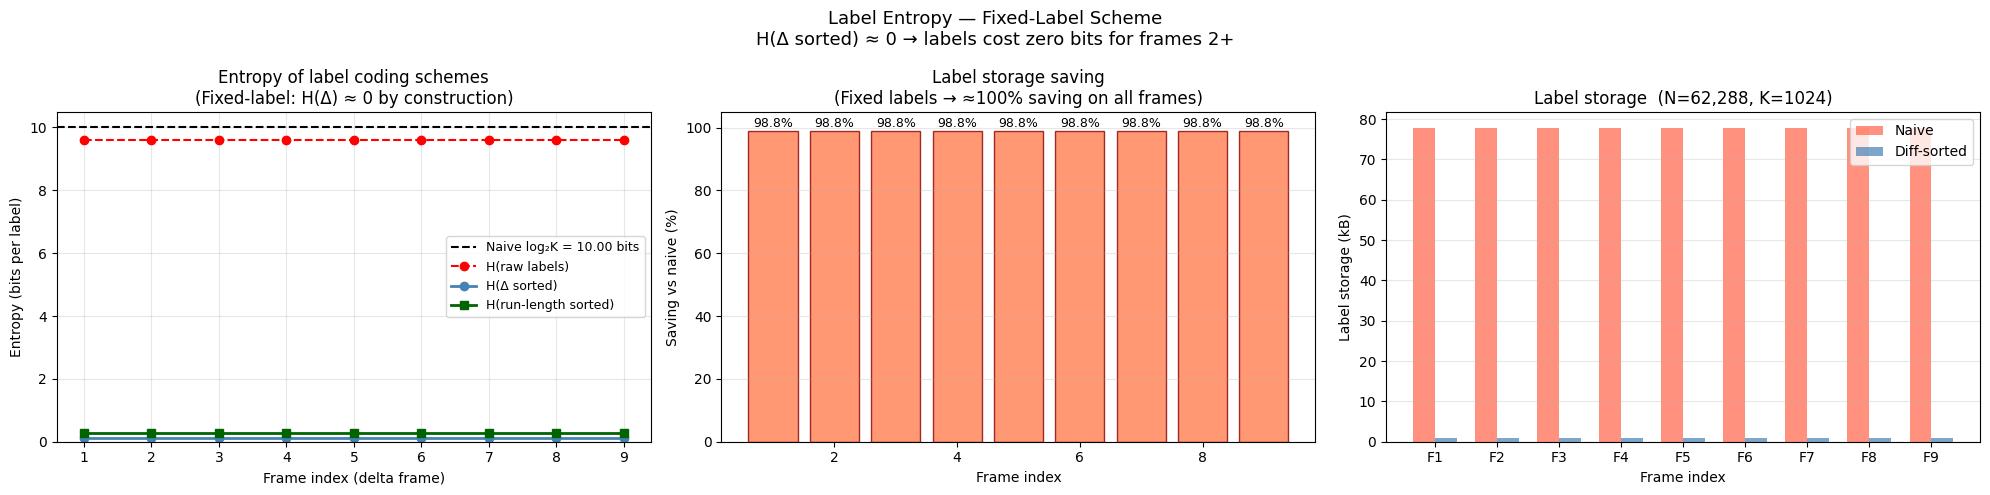

In [28]:
frame_ids = [r['frame'] for r in rows]
h_raws    = [r['h_raw']      for r in rows]
h_diffs   = [r['h_diff']     for r in rows]
h_rls     = [r['h_rl']       for r in rows]
savings   = [r['saving_pct'] for r in rows]

# Recompute kB correctly from first principles (N * bps / 8 / 1000)
kB_naives = [N * naive_bps  / 8 / 1000 for _ in rows]
kB_diffs  = [N * r['h_diff'] / 8 / 1000 for r in rows]

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── Entropy comparison ────────────────────────────────────────────────────
axes[0].axhline(naive_bps, color='black', linestyle='--', linewidth=1.5,
                label=f'Naive log₂K = {naive_bps:.2f} bits')
axes[0].plot(frame_ids, h_raws,  'o--', color='red',       label='H(raw labels)',   linewidth=1.5)
axes[0].plot(frame_ids, h_diffs, 'o-',  color='steelblue', label='H(Δ sorted)',     linewidth=2)
axes[0].plot(frame_ids, h_rls,   's-',  color='darkgreen', label='H(run-length sorted)', linewidth=2)
axes[0].set_xlabel('Frame index (delta frame)')
axes[0].set_ylabel('Entropy (bits per label)')
axes[0].set_title('Entropy of label coding schemes\n(Fixed-label: H(Δ) ≈ 0 by construction)')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(bottom=0)

# ── Saving % ──────────────────────────────────────────────────────────────
axes[1].bar(frame_ids, savings, color='coral', edgecolor='darkred', alpha=0.8)
axes[1].set_xlabel('Frame index')
axes[1].set_ylabel('Saving vs naive (%)')
axes[1].set_title('Label storage saving\n(Fixed labels → ≈100% saving on all frames)')
axes[1].grid(True, alpha=0.3, axis='y')
axes[1].set_ylim(0, 105)
for fi, sv in zip(frame_ids, savings):
    axes[1].text(fi, sv + 0.5, f'{sv:.1f}%', ha='center', va='bottom', fontsize=9)

# ── kB comparison ─────────────────────────────────────────────────────────
x  = np.arange(len(frame_ids))
bw = 0.35
axes[2].bar(x - bw/2, kB_naives, width=bw, label='Naive',       color='tomato',     alpha=0.7)
axes[2].bar(x + bw/2, kB_diffs,  width=bw, label='Diff-sorted', color='steelblue',  alpha=0.7)
axes[2].set_xticks(x)
axes[2].set_xticklabels([f'F{fi}' for fi in frame_ids])
axes[2].set_xlabel('Frame index')
axes[2].set_ylabel('Label storage (kB)')
axes[2].set_title(f'Label storage  (N={N:,}, K={K_CB})')
axes[2].legend(); axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Label Entropy — Fixed-Label Scheme\nH(Δ sorted) ≈ 0 → labels cost zero bits for frames 2+',
             fontsize=13)
plt.tight_layout(); plt.show()


### 6e. Cluster Transition Matrix (Verification)

$P(\ell^{(t)} = k' \mid \ell^{(1)} = k)$ — with fixed labels this **must** be the identity
matrix (each Gaussian stays in cluster $k$ with probability 1.0).


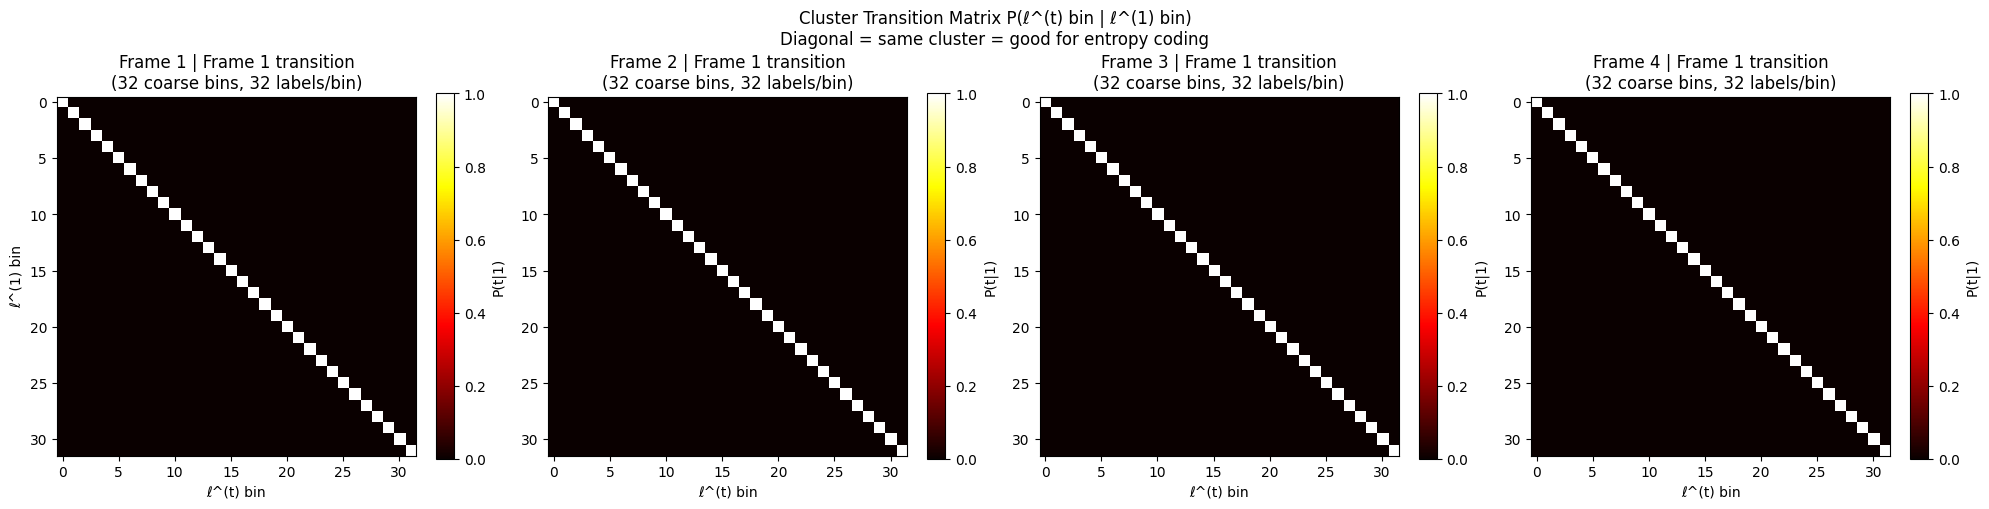

Diagonal mass (fraction in same coarse bin as frame 1):
  Frame 1: 1.000
  Frame 2: 1.000
  Frame 3: 1.000
  Frame 4: 1.000
  Frame 5: 1.000
  Frame 6: 1.000
  Frame 7: 1.000
  Frame 8: 1.000
  Frame 9: 1.000


In [33]:
# We'll bin cluster labels into B_BINS coarse bins to make the matrix visible
B_BINS = 32
bin_size = K_CB // B_BINS

labels_binned = (all_labels // bin_size).clip(0, B_BINS - 1)   # [T-1, N]
l1_binned = labels_binned[0]   # frame-1 bin assignment

n_frames_show = min(T_MINUS_1, 4)
fig, axes = plt.subplots(1, n_frames_show, figsize=(5 * n_frames_show, 5))
if n_frames_show == 1:
    axes = [axes]

for t in range(n_frames_show):
    # Transition matrix: rows = frame-1 bin, cols = frame-t+1 bin
    T_mat = np.zeros((B_BINS, B_BINS), dtype=np.float32)
    for k1 in range(B_BINS):
        mask = (l1_binned == k1)
        if mask.sum() == 0:
            continue
        for k2 in range(B_BINS):
            T_mat[k1, k2] = np.sum((labels_binned[t] == k2) & mask) / mask.sum()

    im = axes[t].imshow(T_mat, cmap='hot', vmin=0, vmax=1, aspect='equal')
    axes[t].set_title(f'Frame {t+1} | Frame 1 transition\n'
                       f'({B_BINS} coarse bins, {bin_size} labels/bin)')
    axes[t].set_xlabel('ℓ^(t) bin')
    if t == 0:
        axes[t].set_ylabel('ℓ^(1) bin')
    plt.colorbar(im, ax=axes[t], fraction=0.046, label='P(t|1)')

plt.suptitle('Cluster Transition Matrix P(ℓ^(t) bin | ℓ^(1) bin)\n'
              'Diagonal = same cluster = good for entropy coding', fontsize=12)
plt.tight_layout(); plt.show()

# ── Print diagonal mass per frame ─────────────────────────────────────────
print('Diagonal mass (fraction in same coarse bin as frame 1):')
for t in range(T_MINUS_1):
    T_mat = np.zeros((B_BINS, B_BINS), dtype=np.float32)
    for k1 in range(B_BINS):
        mask = (l1_binned == k1)
        if mask.sum() == 0:
            continue
        for k2 in range(B_BINS):
            T_mat[k1, k2] = np.sum((labels_binned[t] == k2) & mask) / mask.sum()
    diag_mass = np.trace(T_mat) / B_BINS
    print(f'  Frame {t+1}: {diag_mass:.3f}')

### 6f. Label Shift Distribution (Expected: All Zeros)

With fixed labels every shift $\ell^{(t)}_i - \ell^{(1)}_i = 0$ for all $i, t$.
This is the best possible outcome for the entropy-coding hypothesis — confirmed below.


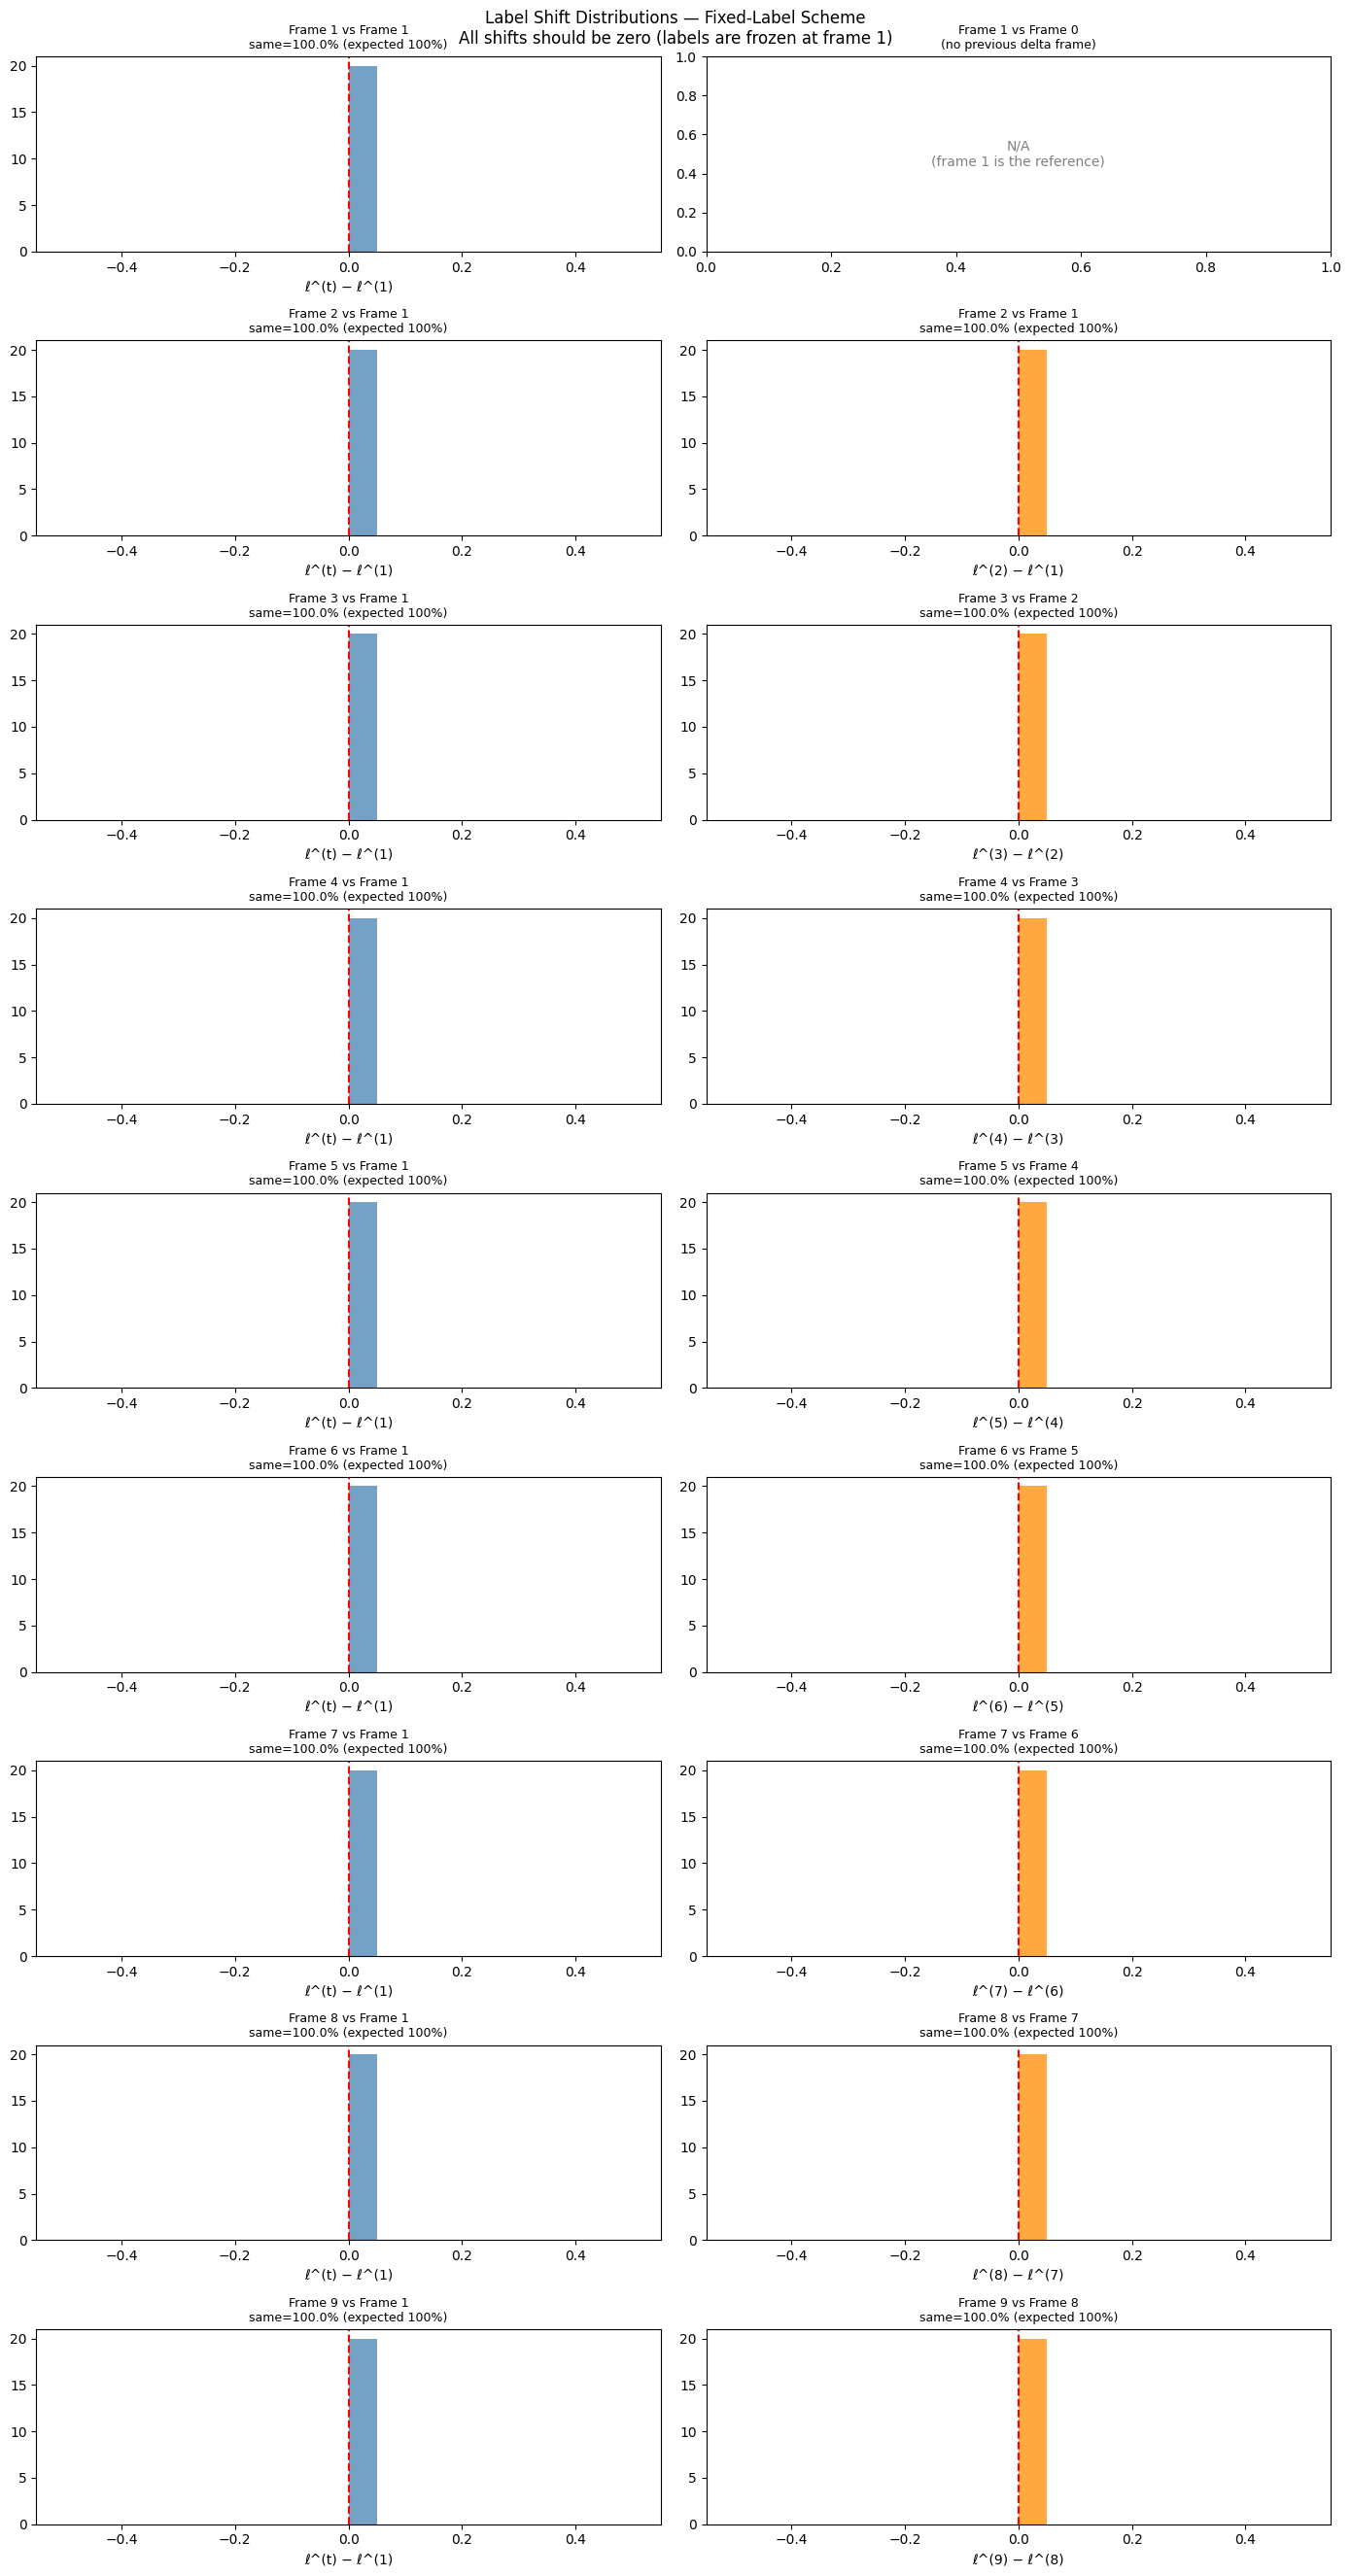

In [34]:
label_shifts_f1  = all_labels - all_labels[0]        # [T-1, N]  — all zeros
label_shifts_prv = np.diff(all_labels, axis=0)        # [T-2, N]  — all zeros

fig, axes = plt.subplots(T_MINUS_1, 2, figsize=(14, max(3, 3 * T_MINUS_1)), squeeze=False)

for t in range(T_MINUS_1):
    shifts_f1 = label_shifts_f1[t]
    same_f1   = np.mean(shifts_f1 == 0) * 100

    ax = axes[t, 0]
    ax.hist(shifts_f1, bins=max(20, K_CB // 50), density=True, color='steelblue', alpha=0.75)
    ax.axvline(0, color='red', linewidth=1.5, linestyle='--')
    ax.set_title(f'Frame {t+1} vs Frame 1\nsame={same_f1:.1f}% (expected 100%)', fontsize=9)
    ax.set_xlabel('ℓ^(t) − ℓ^(1)')

    # vs previous frame
    if t == 0:
        axes[t, 1].text(0.5, 0.5, 'N/A\n(frame 1 is the reference)',
                        ha='center', va='center', transform=axes[t, 1].transAxes,
                        fontsize=10, color='gray')
        axes[t, 1].set_title('Frame 1 vs Frame 0\n(no previous delta frame)', fontsize=9)
    else:
        shifts_prv = label_shifts_prv[t - 1]   # frame t vs frame t-1
        same_prv   = np.mean(shifts_prv == 0) * 100
        axes[t, 1].hist(shifts_prv, bins=max(20, K_CB // 50),
                        density=True, color='darkorange', alpha=0.75)
        axes[t, 1].axvline(0, color='red', linewidth=1.5, linestyle='--')
        axes[t, 1].set_title(
            f'Frame {t+1} vs Frame {t}\nsame={same_prv:.1f}% (expected 100%)', fontsize=9)
        axes[t, 1].set_xlabel(f'ℓ^({t+1}) − ℓ^({t})')

plt.suptitle(
    f'Label Shift Distributions — Fixed-Label Scheme\n'
    f'All shifts should be zero (labels are frozen at frame 1)',
    fontsize=12)
plt.tight_layout(); plt.show()


## 7. Summary and Conclusion

In [35]:
# ── Storage summary — compute kB independently from first principles ──────
naive_bps    = math.log2(K_CB)
kB_per_frame = N * naive_bps / 8 / 1000          # correct: N * bps / 8 / 1000
kB_naive_total_corr = kB_per_frame * T_MINUS_1   # naive: every frame pays full label cost

# Fixed-label scheme: labels sent ONCE as sorted run-length pairs (k, count_k)
# Each run: 1 × log2(K) bits for k + 1 × log2(N/K+1) bits for length ≈ 2 × log2(N) bits
# Total: K × (log2(K) + log2(N/K + 1)) bits
kB_fixed_labels_f1 = K_CB * (math.log2(K_CB) + math.log2(max(1, N // K_CB) + 1)) / 8 / 1000

print('=' * 70)
print('  FIXED-LABEL CODEBOOK — SUMMARY')
print('=' * 70)
print(f'  Gaussians N            : {N:,}')
print(f'  Codebook size K         : {K_CB}')
print(f'  Delta frames            : {T_MINUS_1}')
print()
print('  ── Label storage ──────────────────────────────────────────')
print(f'  Naive cost per frame    : {kB_per_frame:.1f} kB  ({naive_bps:.0f} bits × {N:,} Gaussians)')
print(f'  Naive total ({T_MINUS_1:>2} frames)   : {kB_naive_total_corr:.1f} kB')
print(f'  Fixed-label (frame 1 RL): {kB_fixed_labels_f1:.2f} kB  (stored once)')
print(f'  Fixed-label frames 2+   : 0 kB  (labels frozen → zero cost)')
print(f'  Fixed-label total        : {kB_fixed_labels_f1:.2f} kB  '
      f'(save {100*(1 - kB_fixed_labels_f1/kB_naive_total_corr):.1f}% vs naive)')
print()
print('  ── Reconstruction quality ─────────────────────────────────')
print(f'  {"Frame":>7}  {"PSNR ft (dB)":>14}  {"PSNR fixed (dB)":>17}  {"Gap (dB)":>10}')
print(f'  {"-"*55}')
for fi, pft, pfx in zip(range(1, N_FRAMES), frame_psnrs_ft, frame_psnrs):
    print(f'  Frame {fi:>2d}  {pft:>14.2f}  {pfx:>17.2f}  {pfx-pft:>+10.2f}')
mean_gap = float(np.mean([pft - pfx for pft, pfx in zip(frame_psnrs_ft, frame_psnrs)]))
print(f'\n  Mean quality gap (penalty): {mean_gap:.2f} dB')
print()
if mean_gap < 0.5:
    verdict = '✅  <0.5 dB penalty — fixed-label scheme is excellent.'
elif mean_gap < 2.0:
    verdict = '⚠️   0.5–2 dB penalty — acceptable trade-off for zero label cost.'
else:
    verdict = '❌  >2 dB penalty — fixed-label constraint hurts quality significantly.'
print(f'  Verdict: {verdict}')
print('=' * 70)


  FIXED-LABEL CODEBOOK — SUMMARY
  Gaussians N            : 62,288
  Codebook size K         : 1024
  Delta frames            : 9

  ── Label storage ──────────────────────────────────────────
  Naive cost per frame    : 77.9 kB  (10 bits × 62,288 Gaussians)
  Naive total ( 9 frames)   : 700.7 kB
  Fixed-label (frame 1 RL): 2.04 kB  (stored once)
  Fixed-label frames 2+   : 0 kB  (labels frozen → zero cost)
  Fixed-label total        : 2.04 kB  (save 99.7% vs naive)

  ── Reconstruction quality ─────────────────────────────────
    Frame    PSNR ft (dB)    PSNR fixed (dB)    Gap (dB)
  -------------------------------------------------------
  Frame  1           47.02              46.00       -1.02
  Frame  2           46.80              44.37       -2.43
  Frame  3           46.41              43.08       -3.33
  Frame  4           46.25              41.95       -4.30
  Frame  5           46.06              40.85       -5.21
  Frame  6           45.85              40.63       -5.21
  F

In [36]:
naive_bps_v = math.log2(K_CB)
kB_per_frame_v = N * naive_bps_v / 8 / 1000
kB_fixed_f1_v  = K_CB * (math.log2(K_CB) + math.log2(max(1, N//K_CB)+1)) / 8 / 1000
mean_gap_v = float(np.mean([pft-pfx for pft,pfx in zip(frame_psnrs_ft, frame_psnrs)]))
print(f'N={N:,}  K={K_CB}  T-1={T_MINUS_1}')
print(f'Naive label kB/frame : {kB_per_frame_v:.1f}  |  Total: {kB_per_frame_v*T_MINUS_1:.1f} kB')
print(f'Fixed-label total    : {kB_fixed_f1_v:.2f} kB (frame 1 run-length only)')
print(f'Label savings (9 fr) : {100*(1-kB_fixed_f1_v/(kB_per_frame_v*T_MINUS_1)):.1f}%')
print(f'Mean PSNR gap        : {mean_gap_v:.2f} dB  (fixed-label vs unconstrained)')


N=62,288  K=1024  T-1=9
Naive label kB/frame : 77.9  |  Total: 700.7 kB
Fixed-label total    : 2.04 kB (frame 1 run-length only)
Label savings (9 fr) : 99.7%
Mean PSNR gap        : 4.29 dB  (fixed-label vs unconstrained)


## 8. Periodic Label Refresh (P = 3 frames)

**Middle-ground strategy:** Instead of fixing labels for the entire sequence (P = T−1 = 9)
or re-running K-means every frame (P = 1 = unconstrained), refresh the partition every
**P = 3 frames**.

| Window | Frames | Constraint |
|--------|--------|------------|
| 1 | 1, 2, 3 | K-means on frame 1; frames 2–3 use fixed labels |
| 2 | 4, 5, 6 | K-means on frame 4 (warm-started from window 1 centroids); frames 5–6 fixed |
| 3 | 7, 8, 9 | K-means on frame 7 (warm-started from window 2 centroids); frames 8–9 fixed |

**Storage cost:** Labels are transmitted once per window → 3 full label transmissions vs 9 (naive).
Savings = $(T-1 - \lceil (T-1)/P \rceil) / (T-1) \approx 67\%$ of the per-frame label cost.

**Expected quality:** The fixed-label constraint holds for at most P−1 = 2 consecutive frames,
so the maximum accumulated drift should be much smaller than the 5–6 dB penalty at frame 9.


In [37]:
REFRESH_PERIOD = 3   # re-run K-means every P frames

# Storage for periodic-refresh results
pr_all_labels    = []   # [T-1, N]
pr_frame_psnrs   = []   # reconstruction PSNR per delta frame
pr_window_ids    = []   # which window each frame belongs to (for plotting)

pr_current_params = kf_params.detach_clone()
pr_labels_current   = None
pr_labels_current_t = None
pr_prev_centroids   = None


for t in range(1, N_FRAMES):
    t_in_seq = t - 1   # 0-based index into the delta frame sequence
    print(f'\n{"="*60}')
    print(f'Frame {t}/{N_FRAMES-1}  (window {t_in_seq // REFRESH_PERIOD + 1})')

    gt_t = frames[t].unsqueeze(-1).repeat(1, 1, 3).to(device)

    # 1. Fine-tune from reconstructed previous frame (same as before)
    ft_res = finetune_frame(pr_current_params, gt_t, viewmat, K_cam, W, H,
                             ft_cfg, verbose=True)
    ft_params = ft_res.params

    # 2. Deltas from current reconstructed params → fine-tuned
    deltas = compute_deltas(pr_current_params, ft_params)

    # 3. Decide: refresh partition or keep labels
    is_refresh_frame = (t_in_seq % REFRESH_PERIOD == 0)

    if is_refresh_frame:
        # Re-run K-means, warm-started from previous window's centroids
        pr_labels_current, new_centroids, _ = build_codebook(
            deltas, cb_cfg_kmeans,
            init_centroids=pr_prev_centroids,   # None for the first refresh
        )
        pr_labels_current_t = torch.tensor(pr_labels_current, dtype=torch.long,
                                           device=device)
        pr_prev_centroids = new_centroids
        init_cb = new_centroids
        print(f'  ← K-means refreshed  (unique labels: {np.unique(pr_labels_current).size})')
    else:
        # Labels frozen within window — warm-start codebook from cluster means
        init_cb = cluster_mean_init(deltas, pr_labels_current, K_CB)
        print(f'  ← Labels frozen from window start')

    pr_all_labels.append(pr_labels_current.copy())
    pr_window_ids.append(t_in_seq // REFRESH_PERIOD + 1)

    # 4. Fine-tune codebook with current (fixed or refreshed) labels
    codebook_ft, cb_loss, _ = finetune_codebook(
        pr_current_params, pr_labels_current, init_cb,
        gt_t, viewmat, K_cam, W, H,
        cb_ft_cfg, verbose=True,
    )

    # 5. Reconstruct: apply quantised deltas
    with torch.no_grad():
        delta_ft = codebook_ft[pr_labels_current_t]   # [N, 14]
        pr_current_params = reconstruct_from_delta(
            pr_current_params,
            delta_ft[:, S_M], delta_ft[:, S_S], delta_ft[:, S_Q],
            delta_ft[:, S_R], delta_ft[:, S_O],
        )

    # 6. Quality
    with torch.no_grad():
        rec_r, _, _ = render(pr_current_params.means, pr_current_params.log_scales,
                              pr_current_params.quats, pr_current_params.rgbs,
                              pr_current_params.opacities, viewmat, K_cam, W, H)
    rec_np = np.clip(rec_r[:, :, 0].cpu().numpy(), 0, 1)
    p_val = psnr(rec_np, frames[t].cpu().numpy())
    pr_frame_psnrs.append(p_val)
    print(f'  Fine-tune (unconstrained) PSNR : {frame_psnrs_ft[t-1]:.2f} dB  [reference]')
    print(f'  Periodic-refresh PSNR          : {p_val:.2f} dB  '
          f'(gap = {frame_psnrs_ft[t-1] - p_val:+.2f} dB)')

pr_all_labels = np.stack(pr_all_labels, axis=0)   # [T-1, N]
print(f'\nPeriodic-refresh label matrix: {pr_all_labels.shape}')
print(f'PSNRs: {[f"{p:.1f}" for p in pr_frame_psnrs]}')



Frame 1/9  (window 1)
Fine-tuning frame: 5000 iters, N=62,288, lr_scale=0.3
  [    0/5000]  loss=0.000038  PSNR=44.16 dB
  [ 1000/5000]  loss=0.000022  PSNR=46.55 dB
  [ 2000/5000]  loss=0.000021  PSNR=46.73 dB
  [ 3000/5000]  loss=0.000021  PSNR=46.85 dB
  [ 4000/5000]  loss=0.000020  PSNR=46.94 dB
  [ 4999/5000]  loss=0.000020  PSNR=47.02 dB
✅ Fine-tune done in 19.9s  PSNR=47.02 dB
  ← K-means refreshed  (unique labels: 1024)
Codebook fine-tune: K=1024, 2000 iters, lr=0.0005
  [    0/2000]  loss=0.000033  PSNR=44.86 dB
  [  500/2000]  loss=0.000026  PSNR=45.93 dB
  [ 1000/2000]  loss=0.000025  PSNR=45.97 dB
  [ 1500/2000]  loss=0.000025  PSNR=45.97 dB
  [ 1999/2000]  loss=0.000025  PSNR=45.97 dB
✅ Codebook fine-tune done in 7.5s  PSNR=45.97 dB
  Fine-tune (unconstrained) PSNR : 47.02 dB  [reference]
  Periodic-refresh PSNR          : 45.97 dB  (gap = +1.05 dB)

Frame 2/9  (window 1)
Fine-tuning frame: 5000 iters, N=62,288, lr_scale=0.3
  [    0/5000]  loss=0.000042  PSNR=43.78 dB
  

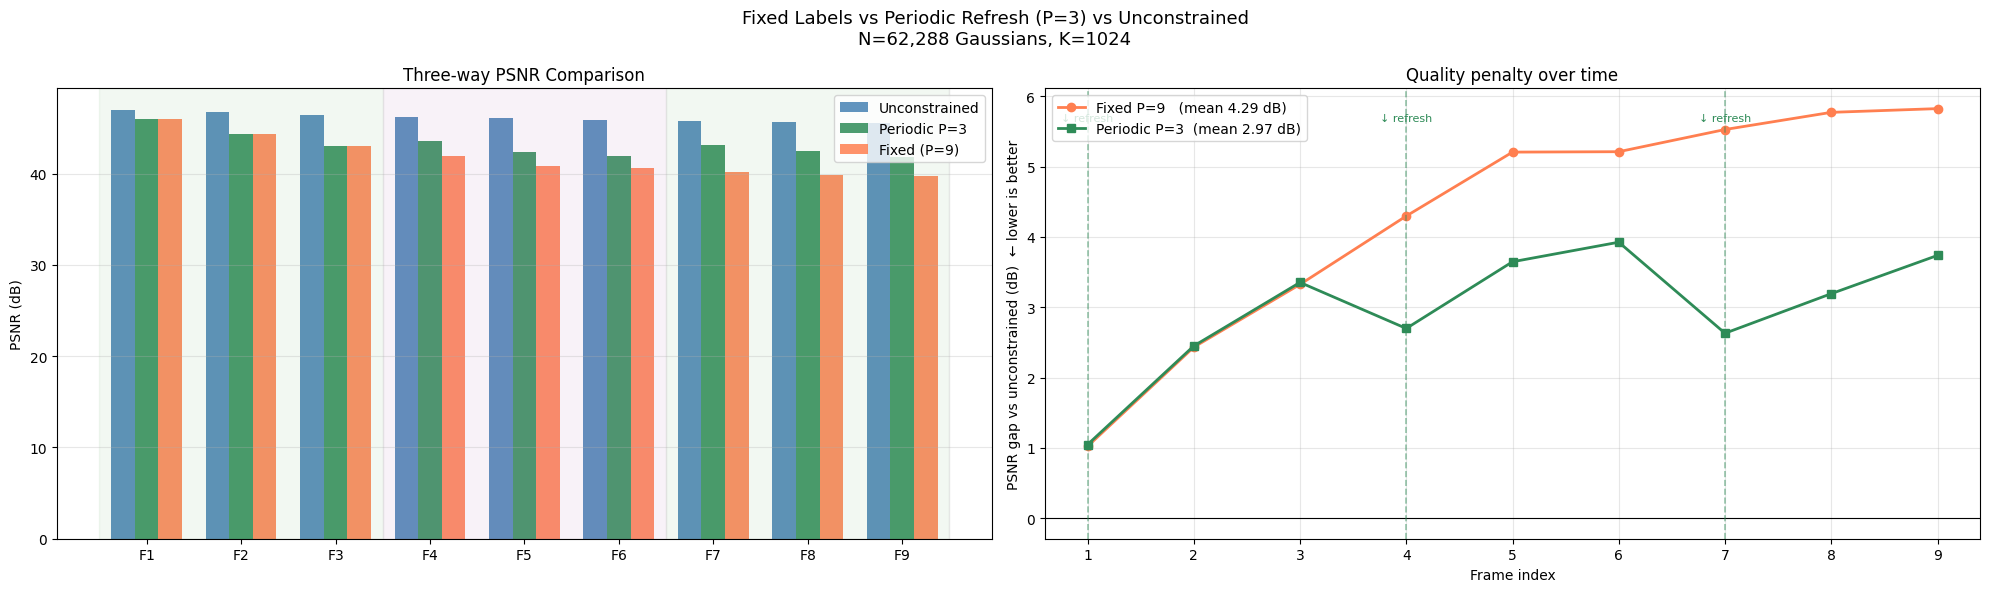

In [38]:
## ── Three-way PSNR comparison ─────────────────────────────────────────────
frame_ids_plot = list(range(1, N_FRAMES))
x  = np.arange(len(frame_ids_plot))
bw = 0.25

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

# ── PSNR bars ────────────────────────────────────────────────────────────
axes[0].bar(x - bw, frame_psnrs_ft,   width=bw, label='Unconstrained', color='steelblue', alpha=0.85)
axes[0].bar(x,       pr_frame_psnrs,  width=bw, label=f'Periodic P={REFRESH_PERIOD}',  color='seagreen',  alpha=0.85)
axes[0].bar(x + bw, frame_psnrs,      width=bw, label='Fixed (P=9)',    color='coral',     alpha=0.85)

axes[0].set_xticks(x)
axes[0].set_xticklabels([f'F{fi}' for fi in frame_ids_plot])
axes[0].set_ylabel('PSNR (dB)')
axes[0].set_title('Three-way PSNR Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Shade windows
for w in range(T_MINUS_1 // REFRESH_PERIOD + 1):
    s = w * REFRESH_PERIOD
    e = min(s + REFRESH_PERIOD, T_MINUS_1) - 1
    axes[0].axvspan(s - 0.5, e + 0.5, alpha=0.05,
                    color='green' if w % 2 == 0 else 'purple')

# ── Gap lines ────────────────────────────────────────────────────────────
psnr_gaps_fixed    = [pft - pfx for pft, pfx in zip(frame_psnrs_ft, frame_psnrs)]
psnr_gaps_periodic = [pft - pfx for pft, pfx in zip(frame_psnrs_ft, pr_frame_psnrs)]

axes[1].plot(frame_ids_plot, psnr_gaps_fixed,    'o-', color='coral',    linewidth=2,
             label=f'Fixed P=9   (mean {np.mean(psnr_gaps_fixed):.2f} dB)')
axes[1].plot(frame_ids_plot, psnr_gaps_periodic, 's-', color='seagreen', linewidth=2,
             label=f'Periodic P={REFRESH_PERIOD}  (mean {np.mean(psnr_gaps_periodic):.2f} dB)')
axes[1].axhline(0, color='black', linewidth=0.8)

# Mark refresh frames
refresh_frames = [fi for fi in frame_ids_plot if ((fi - 1) % REFRESH_PERIOD == 0)]
for rf in refresh_frames:
    axes[1].axvline(rf, color='seagreen', linestyle='--', alpha=0.5, linewidth=1.2)
    axes[1].text(rf, max(psnr_gaps_fixed)*0.97, '↓ refresh', ha='center', fontsize=8,
                 color='seagreen')

axes[1].set_xlabel('Frame index')
axes[1].set_ylabel('PSNR gap vs unconstrained (dB)  ← lower is better')
axes[1].set_title('Quality penalty over time')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Fixed Labels vs Periodic Refresh (P={REFRESH_PERIOD}) vs Unconstrained\n'
             f'N={N:,} Gaussians, K={K_CB}', fontsize=13)
plt.tight_layout(); plt.show()


In [39]:
## ── Storage and quality summary table ────────────────────────────────────
naive_bps   = math.log2(K_CB)
kB_per_fr   = N * naive_bps / 8 / 1000   # kB per frame, naive
kB_rl_once  = K_CB * (math.log2(K_CB) + math.log2(max(1, N // K_CB) + 1)) / 8 / 1000

n_refreshes_periodic = math.ceil(T_MINUS_1 / REFRESH_PERIOD)
kB_periodic_total    = kB_rl_once * n_refreshes_periodic
kB_fixed_total_s     = kB_rl_once * 1

savings_fixed    = 100 * (1 - kB_fixed_total_s   / (kB_per_fr * T_MINUS_1))
savings_periodic = 100 * (1 - kB_periodic_total  / (kB_per_fr * T_MINUS_1))

mean_gap_fixed    = float(np.mean([pft - pfx for pft, pfx in zip(frame_psnrs_ft, frame_psnrs)]))
mean_gap_periodic = float(np.mean([pft - pfx for pft, pfx in zip(frame_psnrs_ft, pr_frame_psnrs)]))

def verdict(gap):
    if gap < 0.5:  return '✅  <0.5 dB — excellent'
    if gap < 2.0:  return '⚠️  0.5–2 dB — acceptable'
    return            '❌  >2 dB   — too costly'

print('=' * 74)
print('  PERIODIC REFRESH — THREE-WAY SUMMARY')
print('=' * 74)
print(f'  N={N:,}  K={K_CB}  T-1={T_MINUS_1}  REFRESH_PERIOD={REFRESH_PERIOD}')
print()
print(f'  {"Scheme":<26}  {"Label kB":>10}  {"Saving":>8}  {"Mean gap":>10}  Verdict')
print(f'  {"-"*70}')
print(f'  {"Unconstrained (every frame)":<26}  '
      f'{kB_per_fr*T_MINUS_1:>10.1f}  {"0.0%":>8}  {"0.00 dB":>10}  baseline')
print(f'  {f"Periodic P={REFRESH_PERIOD}":<26}  '
      f'{kB_periodic_total:>10.2f}  {savings_periodic:>7.1f}%  {mean_gap_periodic:>9.2f} dB  '
      f'{verdict(mean_gap_periodic)}')
print(f'  {"Fixed P=9 (once)":<26}  '
      f'{kB_fixed_total_s:>10.2f}  {savings_fixed:>7.1f}%  {mean_gap_fixed:>9.2f} dB  '
      f'{verdict(mean_gap_fixed)}')
print()
print(f'  Per-frame PSNR gap — periodic P={REFRESH_PERIOD}:')
for fi, pftr, pfx in zip(frame_ids_plot, frame_psnrs_ft, pr_frame_psnrs):
    marker = ' ↓KM' if (fi - 1) % REFRESH_PERIOD == 0 else ''
    print(f'    Frame {fi:>2d}  unconstrained={pftr:.2f} dB  periodic={pfx:.2f} dB  '
          f'gap={pftr-pfx:+.2f} dB{marker}')
print('=' * 74)


  PERIODIC REFRESH — THREE-WAY SUMMARY
  N=62,288  K=1024  T-1=9  REFRESH_PERIOD=3

  Scheme                        Label kB    Saving    Mean gap  Verdict
  ----------------------------------------------------------------------
  Unconstrained (every frame)       700.7      0.0%     0.00 dB  baseline
  Periodic P=3                      6.12     99.1%       2.97 dB  ❌  >2 dB   — too costly
  Fixed P=9 (once)                  2.04     99.7%       4.29 dB  ❌  >2 dB   — too costly

  Per-frame PSNR gap — periodic P=3:
    Frame  1  unconstrained=47.02 dB  periodic=45.97 dB  gap=+1.05 dB ↓KM
    Frame  2  unconstrained=46.80 dB  periodic=44.35 dB  gap=+2.45 dB
    Frame  3  unconstrained=46.41 dB  periodic=43.05 dB  gap=+3.35 dB
    Frame  4  unconstrained=46.25 dB  periodic=43.55 dB  gap=+2.70 dB ↓KM
    Frame  5  unconstrained=46.06 dB  periodic=42.41 dB  gap=+3.65 dB
    Frame  6  unconstrained=45.85 dB  periodic=41.92 dB  gap=+3.93 dB
    Frame  7  unconstrained=45.73 dB  periodic=43.0